In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import ks_2samp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.combine import SMOTEENN

In [3]:
df = pd.read_csv('../Data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
display(df.describe())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
num_fraud = np.sum(df['Class'] == 1)

print(f'Number of fraudulent transactions: {num_fraud}')
print(f'Percentage of fraudulent transactions: {num_fraud / len(df) * 100:.4f}%')

Number of fraudulent transactions: 492
Percentage of fraudulent transactions: 0.1727%


(31,)


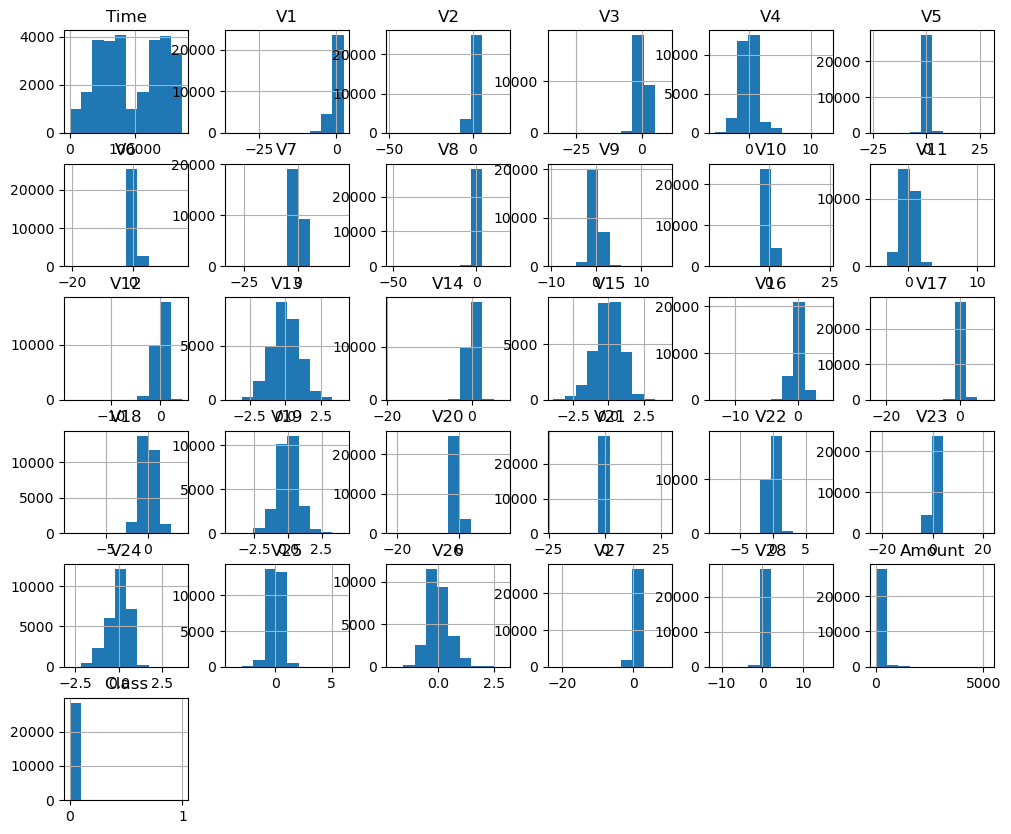

In [6]:
df_sample = df.sample(frac=0.1, random_state=42)

cat_cols = df_sample.select_dtypes(include=['object', 'category']).columns
num_cols = df_sample.select_dtypes(include=['int64', 'float64']).columns

print(num_cols.shape)
    
df_sample.hist(figsize=(12, 10))
plt.show()

In [7]:
df_0 = df[df['Class'] == 0]
df_1 = df[df['Class'] == 1]

n = len(df_1)

df_0_sampled = df_0.sample(n=n, random_state=42)

df_balanced = pd.concat([df_0_sampled, df_1])

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced['Class'].value_counts())

Class
1    492
0    492
Name: count, dtype: int64


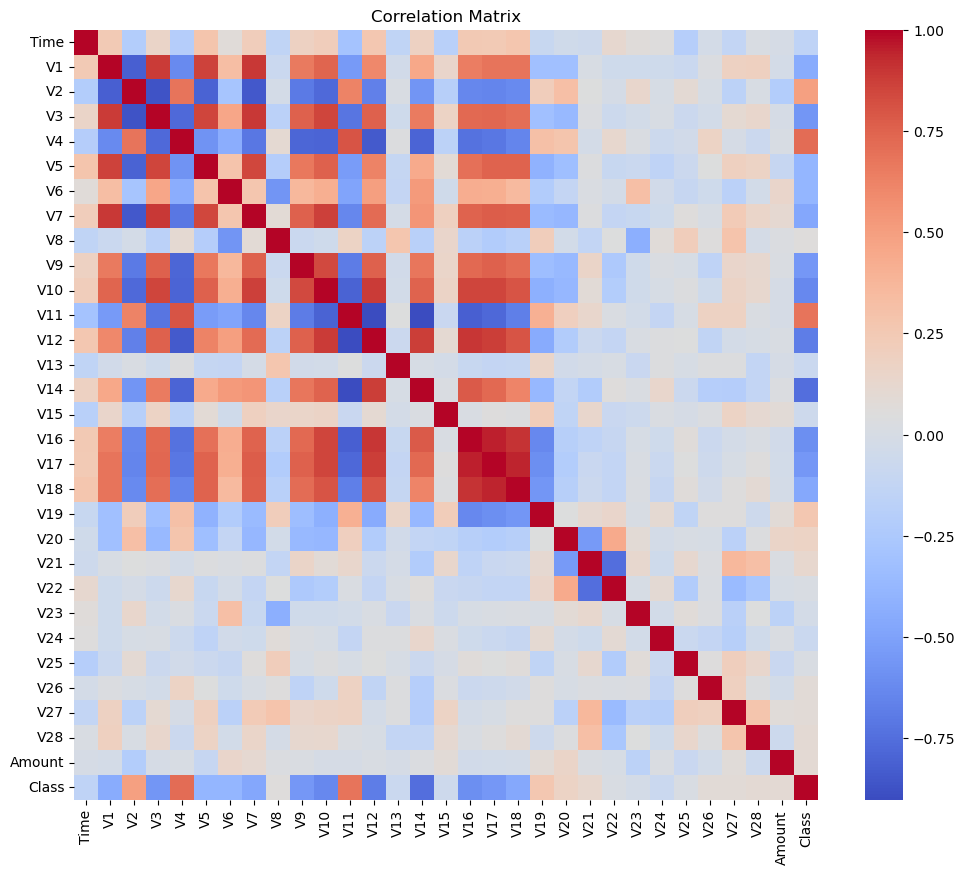

In [8]:
corr_matrix = df_balanced.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [9]:
import numpy as np

corr = corr_matrix.copy()

threshold = 0.5

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

filtered = corr.where(mask)

result = (
    filtered.stack()
    .reset_index()
)

result.columns = ['feature_1', 'feature_2', 'correlation']

result = result[result['correlation'].abs() > threshold]

print(result)

    feature_1 feature_2  correlation
30         V1        V2    -0.816943
31         V1        V3     0.882471
32         V1        V4    -0.619965
33         V1        V5     0.865225
35         V1        V7     0.889875
..        ...       ...          ...
375       V17       V19    -0.599122
386       V17     Class    -0.559169
387       V18       V19    -0.564216
410       V20       V21    -0.541566
420       V21       V22    -0.747431

[106 rows x 3 columns]


Top features by distribution difference:
   feature  ks_score
14     V14  0.842839
10     V10  0.804291
12     V12  0.783908
4       V4  0.766404
11     V11  0.756067
17     V17  0.745173
3       V3  0.703682
16     V16  0.686506
7       V7  0.660578
2       V2  0.633201


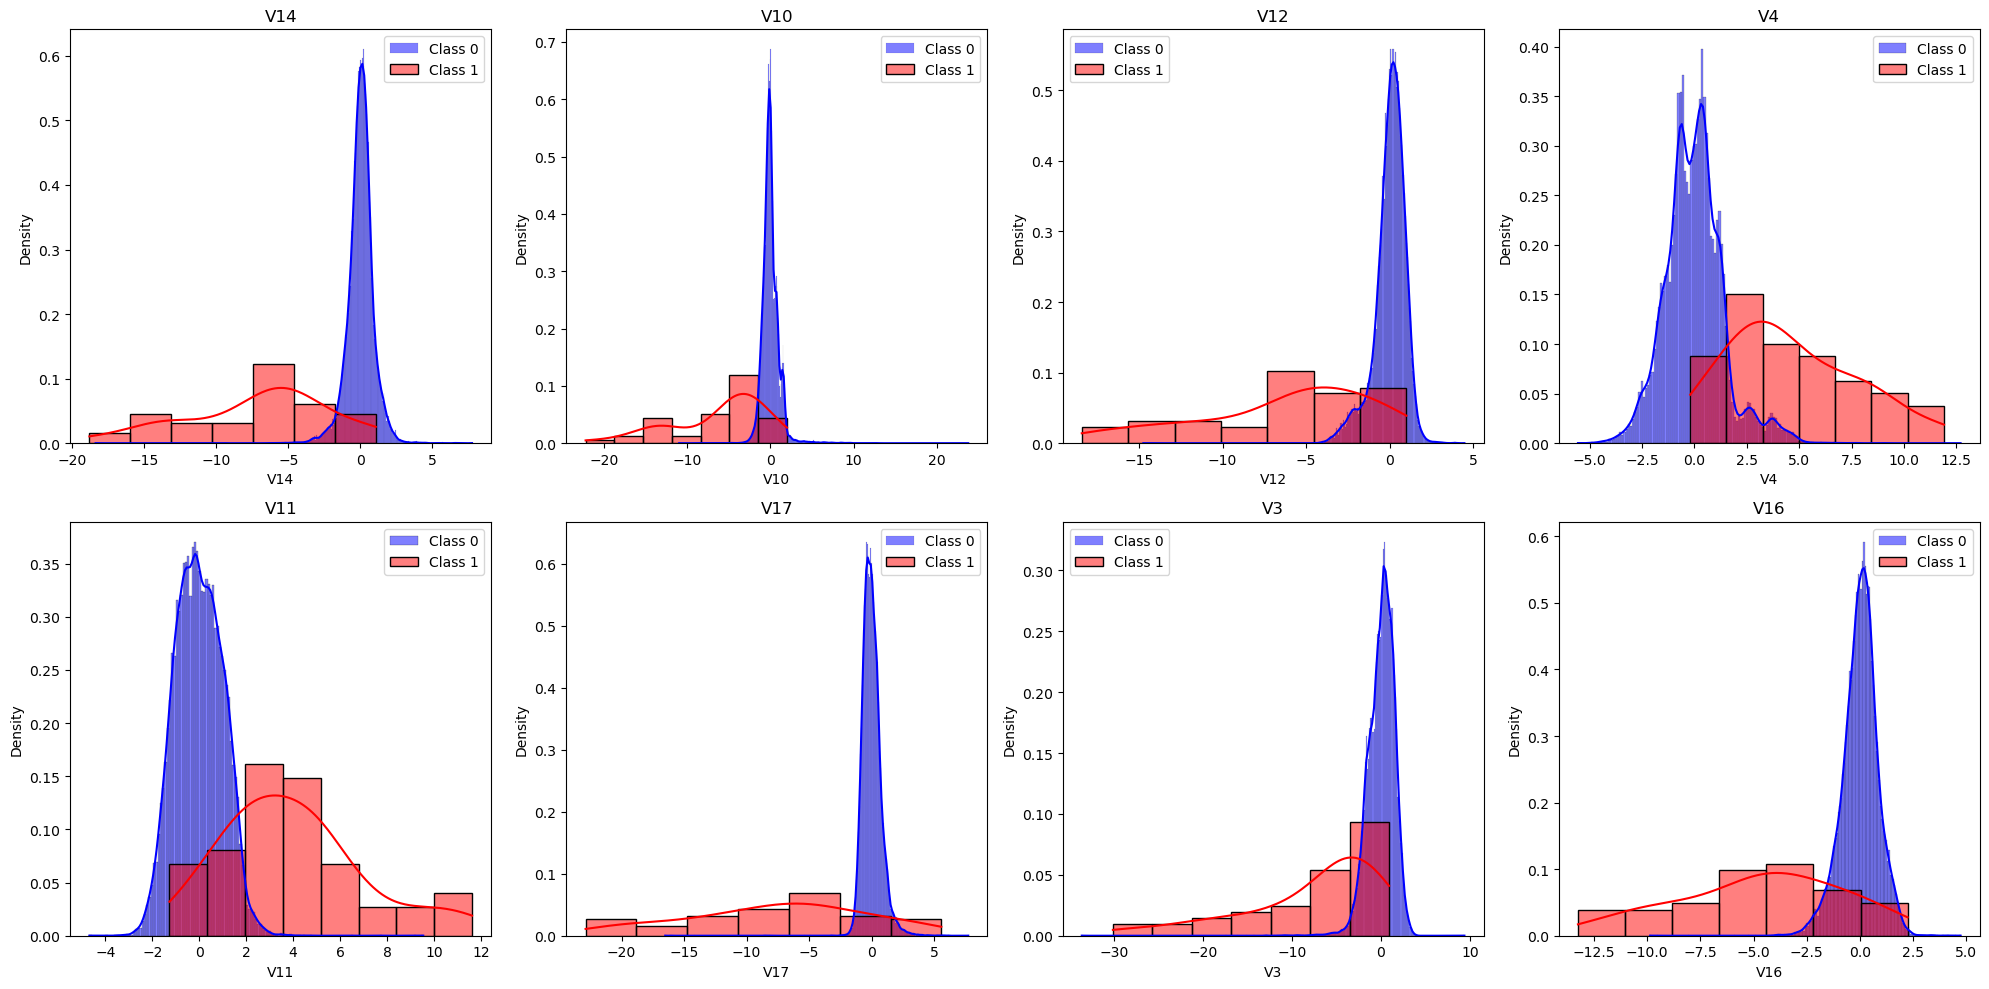

In [10]:
target_col = 'Class'


num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = [col for col in num_cols if col != target_col]

results = []

for col in num_cols:
    class0 = df[df[target_col] == 0][col].dropna()
    class1 = df[df[target_col] == 1][col].dropna()
    
    stat, _ = ks_2samp(class0, class1)
    results.append((col, stat))

ks_df = pd.DataFrame(results, columns=['feature', 'ks_score'])

ks_df = ks_df.sort_values(by='ks_score', ascending=False)

print("Top features by distribution difference:")
print(ks_df.head(10))

top_k = 8
top_features = ks_df.head(top_k)['feature'].tolist()

n_cols_plot = 4
n_rows = int(np.ceil(len(top_features) / n_cols_plot))

fig, axes = plt.subplots(n_rows, n_cols_plot, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    
    sns.histplot(
        df_sample[df_sample[target_col] == 0][feature],
        color='blue', label='Class 0',
        stat='density', kde=True, alpha=0.5, ax=ax
    )
    
    sns.histplot(
        df_sample[df_sample[target_col] == 1][feature],
        color='red', label='Class 1',
        stat='density', kde=True, alpha=0.5, ax=ax
    )
    
    ax.set_title(feature)
    ax.legend()

for i in range(len(top_features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [11]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Original class distribution:")
print(y.value_counts(normalize=True))

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))


Original class distribution:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

Train class distribution:
Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64

Test class distribution:
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


In [12]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [13]:
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (X_train < lower_bound) | (X_train > upper_bound)

print((outliers.sum() / X_train.shape[0]) * 100)


Time       0.000000
V1         2.474928
V2         4.728653
V3         1.180188
V4         3.931620
V5         4.303364
V6         8.019926
V7         3.121420
V8         8.432926
V9         2.918212
V10        3.317167
V11        0.268165
V12        5.379095
V13        1.168777
V14        4.968729
V15        1.009897
V16        2.856328
V17        2.573679
V18        2.670236
V19        3.580943
V20        9.779016
V21        5.060019
V22        0.464790
V23        6.503105
V24        1.661656
V25        1.895148
V26        1.987316
V27       13.716781
V28       10.680068
Amount    11.181286
dtype: float64


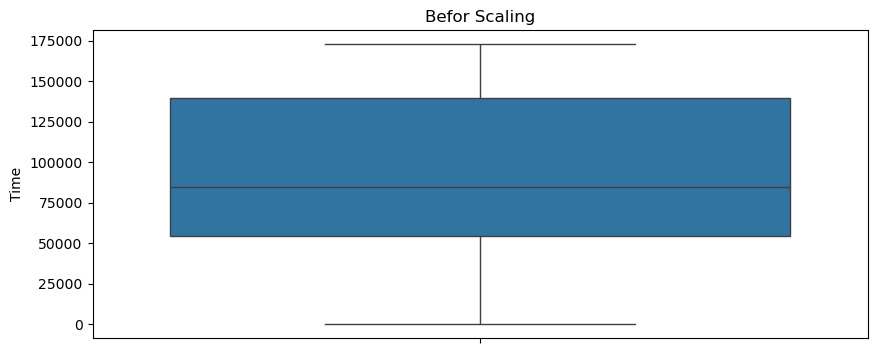

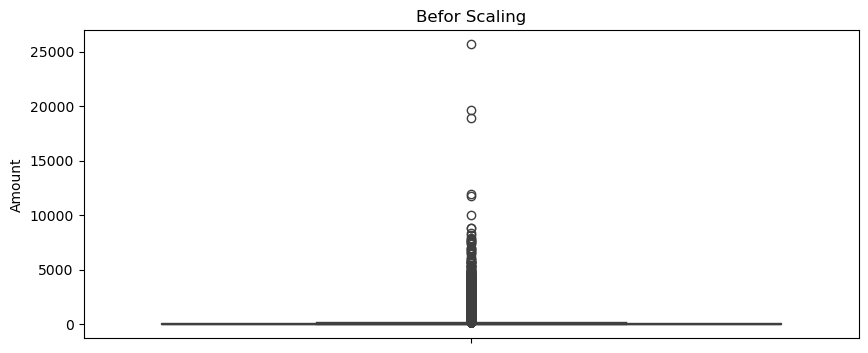

In [14]:
plt.figure(figsize=(10,4))
plt.title("Befor Scaling")
sns.boxplot(data=X_train['Time'])
plt.figure(figsize=(10,4))
sns.boxplot(data=X_train['Amount'])
plt.title("Befor Scaling")
plt.show()

In [15]:
scaler = RobustScaler()

cols_to_scale = ['Time', 'Amount']

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
X_train.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,227845.000000,227845.000000,227845.000000,227845.000000,227845.000000,227845.000000,227845.000000,227845.000000,227845.000000,227845.000000,...,227845.000000,227845.000000,227845.000000,227845.000000,227845.000000,227845.000000,227845.000000,227845.000000,227845.000000,227845.000000
mean,0.118400,0.000795,-0.000481,-0.000383,-0.000020,0.000175,-0.001171,0.000077,-0.000434,0.000702,...,-0.000999,0.000370,0.000303,0.000050,-0.000277,-0.000655,0.000126,-0.000070,0.000154,0.921034
std,0.557795,1.958926,1.649092,1.515292,1.415867,1.379569,1.331218,1.238431,1.191482,1.097351,...,0.770806,0.734963,0.725735,0.627419,0.605322,0.521236,0.481939,0.404934,0.326939,3.489528
min,-0.996112,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-54.497720,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,-0.306193
25%,-0.359155,-0.919893,-0.598761,-0.891767,-0.847111,-0.692100,-0.768603,-0.553481,-0.207839,-0.640307,...,-0.211651,-0.228250,-0.542056,-0.161932,-0.354843,-0.316907,-0.326491,-0.070740,-0.052931,-0.227697
50%,0.000000,0.018692,0.064746,0.179859,-0.021361,-0.054757,-0.274156,0.040420,0.023219,-0.050653,...,-0.062606,-0.029280,0.006599,-0.010983,0.040778,0.016081,-0.051623,0.001463,0.011221,0.000000
75%,0.640845,1.315616,0.803876,1.026457,0.742281,0.611259,0.397501,0.570530,0.327824,0.598254,...,0.132702,0.186365,0.528282,0.147589,0.438966,0.349880,0.240835,0.091180,0.078118,0.772303
max,1.033488,2.451888,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,39.420904,27.202839,10.503090,22.528412,4.584549,6.070850,3.517346,31.612198,33.847808,357.260404


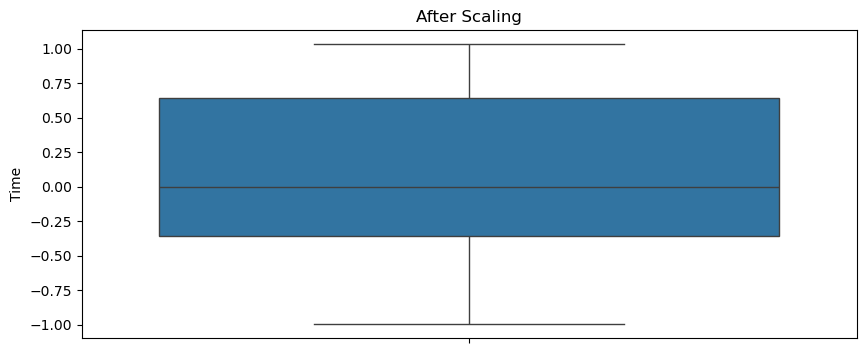

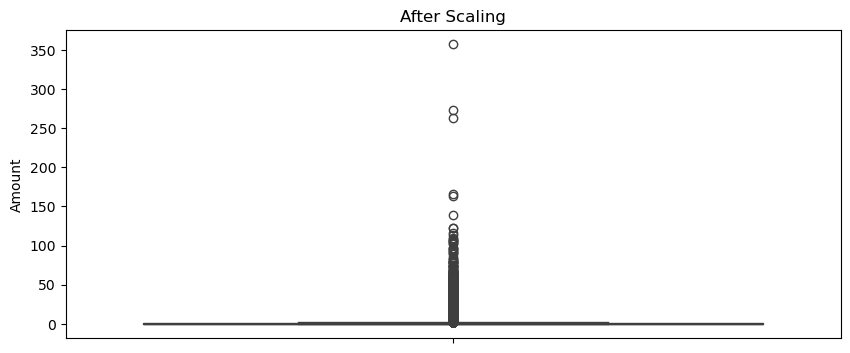

In [16]:
plt.figure(figsize=(10,4))
plt.title("After Scaling")
sns.boxplot(data=X_train['Time'])
plt.figure(figsize=(10,4))
sns.boxplot(data=X_train['Amount'])
plt.title("After Scaling")
plt.show()

In [ ]:
smote_enn = SMOTEENN(random_state=42)
print("Before resampling", y_train.value_counts())

X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train, y_train)

Before resampling Class
0    227451
1       394
Name: count, dtype: int64
Before resampling Class
0    227451
1       394
Name: count, dtype: int64


In [18]:
print("After resampling", y_train_resampled.value_counts())

After resampling Class
1    227451
0    227018
Name: count, dtype: int64


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import lightgbm as lgb
import optuna

In [21]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    min_samples_split=2,
    n_jobs=-1
)

rf_model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [22]:
y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.85      0.82        98

    accuracy                           1.00     56962
   macro avg       0.90      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962



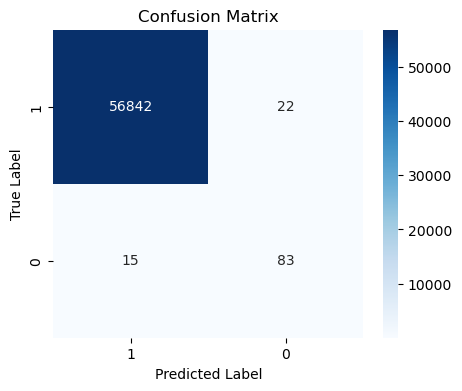

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['1', '0'], yticklabels=['1', '0'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [24]:
lgbm_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    num_leaves=100,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

fit_params = {
    "eval_set" : [(X_test, y_test)],
    "eval_metric" : "auc",
    "callbacks" : [lgb.early_stopping(stopping_rounds=50)]
}

lgbm_model.fit(X_train, y_train, **fit_params)

[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016496 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[86]	valid_0's auc: 0.960791	valid_0's binary_logloss: 0.00295898


LGBMClassifier(class_weight='balanced', n_estimators=1000, n_jobs=-1,
               num_leaves=100, random_state=42)

In [25]:
y_pred = lgbm_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.83      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



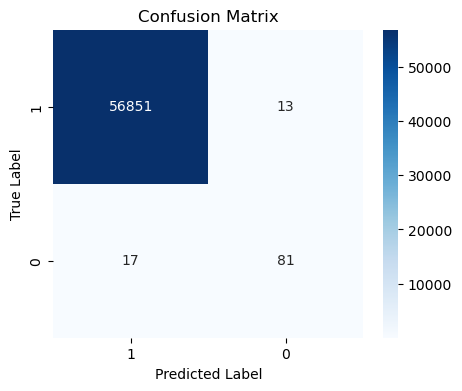

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['1', '0'], yticklabels=['1', '0'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [49]:
from xgboost import XGBClassifier
xgb_parameters = {
    "objective": "binary:logistic",
    "n_estimators": 1000,
    "learning_rate": 0.1,
    "max_depth": 6,
    "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum(),
    "random_state": 42,
    "n_jobs" : -1,
    "device" : "gpu",
    "eval_metric" : "map"
}
xgb_model = XGBClassifier(**xgb_parameters)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred1 = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.95      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
from sklearn.metrics import f1_score
probabilities = xgb_model.predict_proba(X_test)[:, 1]

for thr in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]:
    predictions = (probabilities >= thr).astype(int)
    print(f"{thr} : {f1_score(y_test, predictions)}")

0.1 : 0.83
0.2 : 0.8556701030927835
0.3 : 0.8586387434554974
0.4 : 0.8631578947368421
0.5 : 0.8631578947368421
0.6 : 0.8631578947368421
0.7 : 0.8677248677248677
0.8 : 0.8770053475935828
0.9 : 0.8695652173913043
1 : 0.13333333333333333


In [ ]:
import optuna
import xgboost as xgb
from sklearn.metrics import average_precision_score

weight = y_train.value_counts()[0] / y_train.value_counts()[1]

def objective(trial):
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'aucpr',
        'tree_method': 'hist',
        'random_state': 42,
        'n_jobs': -1,
        'scale_pos_weight': weight,
        'device' : 'gpu',
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 0.5)
    }

    model = xgb.XGBClassifier(**param)
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    
    y_proba = model.predict_proba(X_test)[:, 1]

    pr_auc = average_precision_score(y_test, y_proba)
    
    return pr_auc

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("Best Parameters:", study.best_params)
print("Best PR-AUC:", study.best_value)

[I 2026-05-22 11:21:05,514] A new study created in memory with name: no-name-bfc77374-2cc4-4fbd-aa60-6abeac285e26
[I 2026-05-22 11:21:07,127] Trial 0 finished with value: 0.8777409081761717 and parameters: {'n_estimators': 214, 'max_depth': 9, 'learning_rate': 0.08897829702961924, 'subsample': 0.6025580530637845, 'colsample_bytree': 0.740696295344067, 'gamma': 0.4923556054532494}. Best is trial 0 with value: 0.8777409081761717.
[I 2026-05-22 11:21:08,183] Trial 1 finished with value: 0.697018611948641 and parameters: {'n_estimators': 325, 'max_depth': 3, 'learning_rate': 0.013638806043408717, 'subsample': 0.6868947544485603, 'colsample_bytree': 0.8930044381947202, 'gamma': 0.27541659081861863}. Best is trial 0 with value: 0.8777409081761717.
[I 2026-05-22 11:21:09,473] Trial 2 finished with value: 0.8820359699433473 and parameters: {'n_estimators': 215, 'max_depth': 8, 'learning_rate': 0.07501317544434263, 'subsample': 0.9735154515907396, 'colsample_bytree': 0.7175295911060944, 'gamma'

Best Parameters: {'n_estimators': 425, 'max_depth': 6, 'learning_rate': 0.0920545178079246, 'subsample': 0.8449686497165714, 'colsample_bytree': 0.6037195384277637, 'gamma': 0.03621133548385678}
Best PR-AUC: 0.8870818780881294


In [56]:
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'tree_method': 'hist',
    'random_state': 42,
    'n_jobs': -1,
    'scale_pos_weight': weight,
    'device' : 'gpu'
}

xgb_model = xgb.XGBClassifier(**params, **study.best_params)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred = xgb_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.84      0.87        98

    accuracy                           1.00     56962
   macro avg       0.95      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [65]:
probabilities = xgb_model.predict_proba(X_test)[:, 1]

thresholds = []
for thr in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]:
    predictions = (probabilities >= thr).astype(int)
    thresholds.append([thr, f1_score(y_test, predictions)])

best = max(thresholds, key=lambda x: x[1])
print(f"the best threshold is {best}")

the best threshold is [0.9, 0.8791208791208791]


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

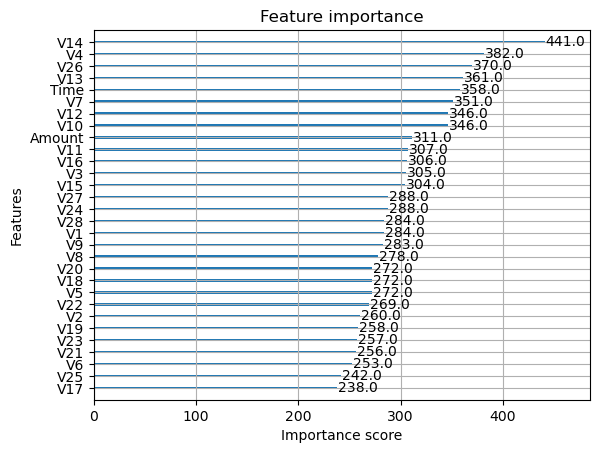

In [67]:
xgb.plot_importance(xgb_model)